In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [46]:
df = pd.read_csv("forestfires_python1.csv")

In [47]:
df.head()

,X,Y,MONTH,DAY,FFMC(Fine Fuel Moisture Code),DMC(Duff Moisture Code),DC(Drought Code),ISI(Initial Spread Index),TEMPERATURE,RH( Relative Humidity),WIND,RAIN,AREA
0,7,5,March,Friday,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,October,Tuesday,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,October,Saturday,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,March,Friday,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,March,Sunday,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### Objective 1: Analyze the distribution and severity of forest fire area burned

In [48]:
df['AREA'].skew()

np.float64(12.846933533934868)

In [49]:
sns.set(style="whitegrid")

In [50]:
plt.figure(figsize=(16, 5))

<Figure size 1600x500 with 0 Axes>

<Figure size 1600x500 with 0 Axes>

Text(0.5, 1.0, 'Histogram & KDE of Area Burned')

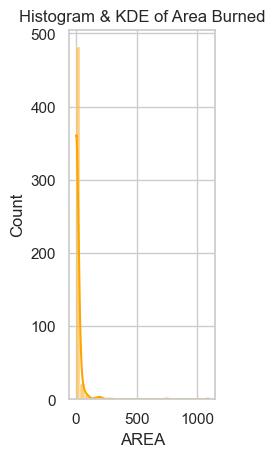

In [51]:
# 1. Histogram + KDE
plt.subplot(1, 3, 1)
sns.histplot(df['AREA'], bins=30, kde=True, color='orange')
plt.title("Histogram & KDE of Area Burned")


Text(0.5, 1.0, 'Boxplot of Area Burned')

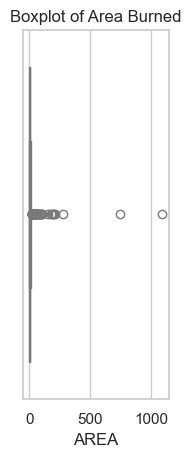

In [52]:
# 2. Box Plot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['AREA'], color='lightblue')
plt.title("Boxplot of Area Burned")


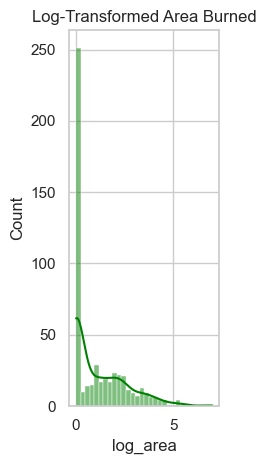

In [53]:
# 3. Log Transform (adding 1 to avoid log(0))
df['log_area'] = np.log1p(df['AREA'])

# Plot log-transformed histogram
plt.subplot(1, 3, 3)
sns.histplot(df['log_area'], bins=30, kde=True, color='green')
plt.title("Log-Transformed Area Burned")

plt.tight_layout()
plt.show()

Skewness before log transform: 12.846933533934868


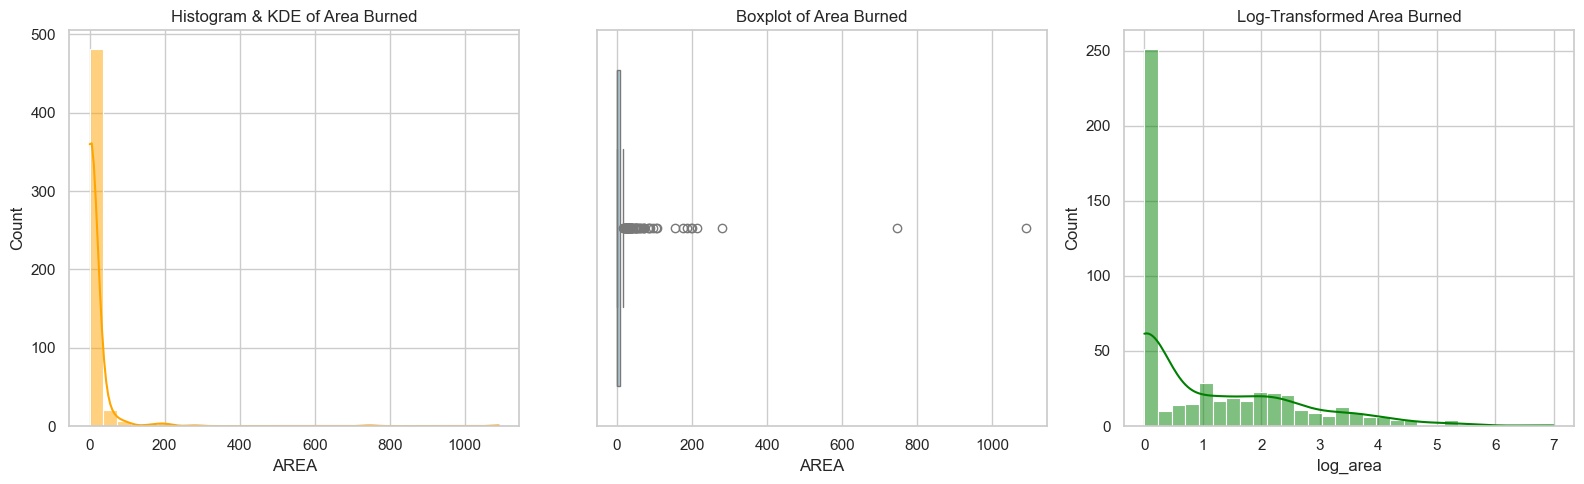

In [54]:

# Basic check
print("Skewness before log transform:", df['AREA'].skew())

# Set style
sns.set(style="whitegrid")

# Create subplots
plt.figure(figsize=(16, 5))

# 1. Histogram + KDE
plt.subplot(1, 3, 1)
sns.histplot(df['AREA'], bins=30, kde=True, color='orange')
plt.title("Histogram & KDE of Area Burned")

# 2. Box Plot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['AREA'], color='lightblue')
plt.title("Boxplot of Area Burned")

# 3. Log Transform (adding 1 to avoid log(0))
df['log_area'] = np.log1p(df['AREA'])

# Plot log-transformed histogram
plt.subplot(1, 3, 3)
sns.histplot(df['log_area'], bins=30, kde=True, color='green')
plt.title("Log-Transformed Area Burned")

plt.tight_layout()
plt.show()


### 1. Here’s a summary of the outcomes from the analysis:
### OBJECTIVE 1: Analyze the distribution and severity of forest fire area burned
* Skewness Before Transformation: The skewness of the 'AREA' column is checked before applying any transformation, revealing a skewed distribution.
* Histogram & KDE: The histogram with KDE of the 'AREA' column shows a right-skewed distribution, indicating that most areas burned are smaller,with a larger outliers.
* Box Plot: The boxplot highlights the presence of outliers in the 'AREA' data, confirming that a few large fires are contributing to the skew.

### objective 2: Understand Temporal Patterns of Forest Fires

In [55]:
print(df['MONTH'].unique())
print(df['DAY'].unique())


['March' 'October' 'August' 'September' 'April' 'June' 'July' 'February'
 'January' 'December' 'May' 'November']
['Friday' 'Tuesday' 'Saturday' 'Sunday' 'Monday' 'Wednesday' 'Thursday']


In [56]:
print(df[['MONTH', 'DAY']].head())

     MONTH       DAY
0    March    Friday
1  October   Tuesday
2  October  Saturday
3    March    Friday
4    March    Sunday


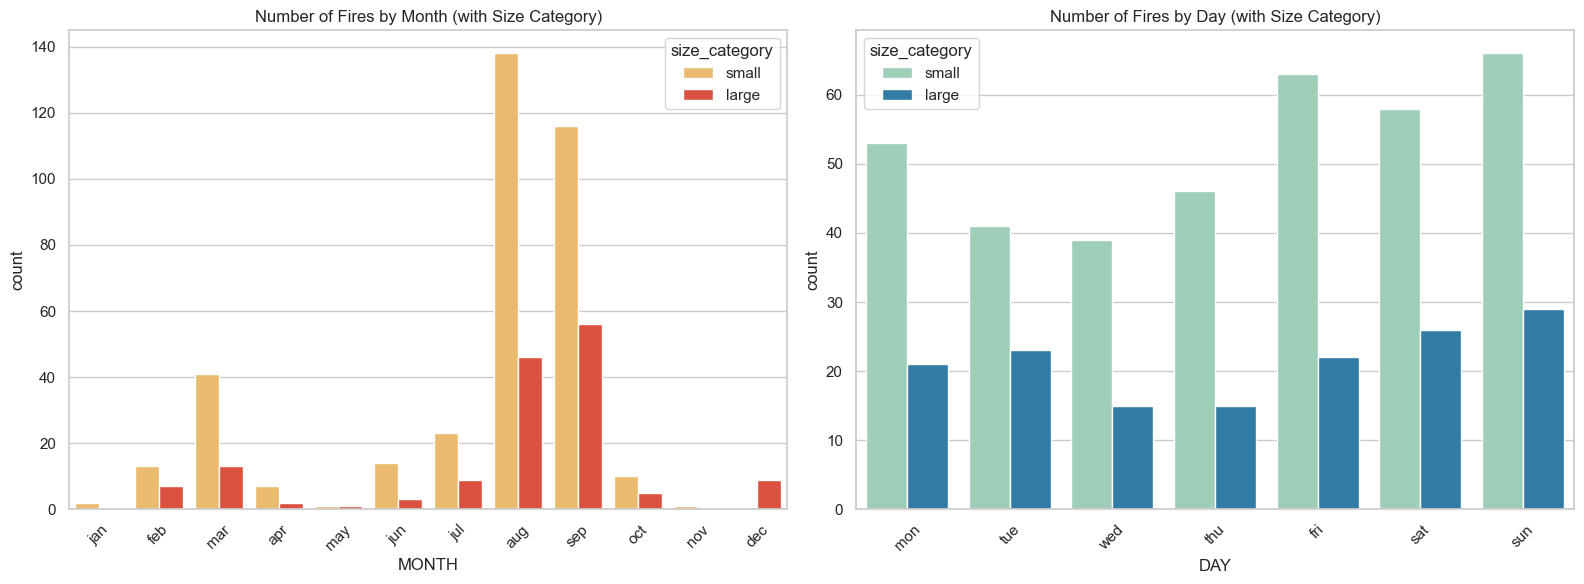

In [57]:

# Step 1: Convert to lowercase
df['MONTH'] = df['MONTH'].str.lower()
df['DAY'] = df['DAY'].str.lower()

# Step 2: Define correct order
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

# Step 3: Map full names to abbreviations
month_map = {
    'january': 'jan', 'february': 'feb', 'march': 'mar', 'april': 'apr',
    'may': 'may', 'june': 'jun', 'july': 'jul', 'august': 'aug',
    'september': 'sep', 'october': 'oct', 'november': 'nov', 'december': 'dec'
}
day_map = {
    'monday': 'mon', 'tuesday': 'tue', 'wednesday': 'wed', 'thursday': 'thu',
    'friday': 'fri', 'saturday': 'sat', 'sunday': 'sun'
}

df['MONTH'] = df['MONTH'].map(month_map)
df['DAY'] = df['DAY'].map(day_map)

# Step 4: Set as categorical with order
df['MONTH'] = pd.Categorical(df['MONTH'], categories=month_order, ordered=True)
df['DAY'] = pd.Categorical(df['DAY'], categories=day_order, ordered=True)

# Step 5: Create size category
df['size_category'] = df['AREA'].apply(lambda x: 'small' if x <= 5 else 'large')

# Step 6: Plot the final graphs
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='MONTH', hue='size_category', palette='YlOrRd')
plt.title("Number of Fires by Month (with Size Category)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='DAY', hue='size_category', palette='YlGnBu')
plt.title("Number of Fires by Day (with Size Category)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


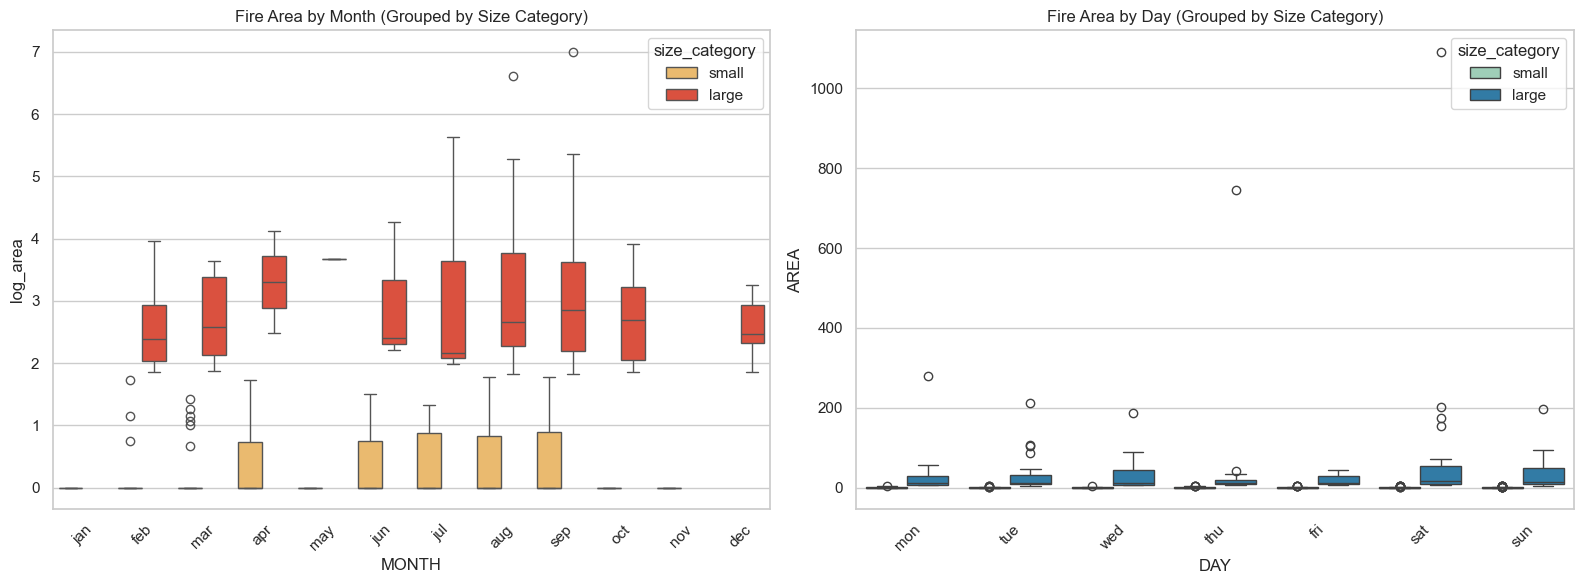

In [60]:
plt.figure(figsize=(16, 6))

# Boxplot by MONTH with hue
plt.subplot(1, 2, 1)
# Use this if AREA has extreme outliers
sns.boxplot(data=df, x='MONTH', y='log_area', hue='size_category', palette='YlOrRd')

plt.title("Fire Area by Month (Grouped by Size Category)")
plt.xticks(rotation=45)

# Boxplot by DAY with hue
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='DAY', y='AREA', hue='size_category', palette='YlGnBu')
plt.title("Fire Area by Day (Grouped by Size Category)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


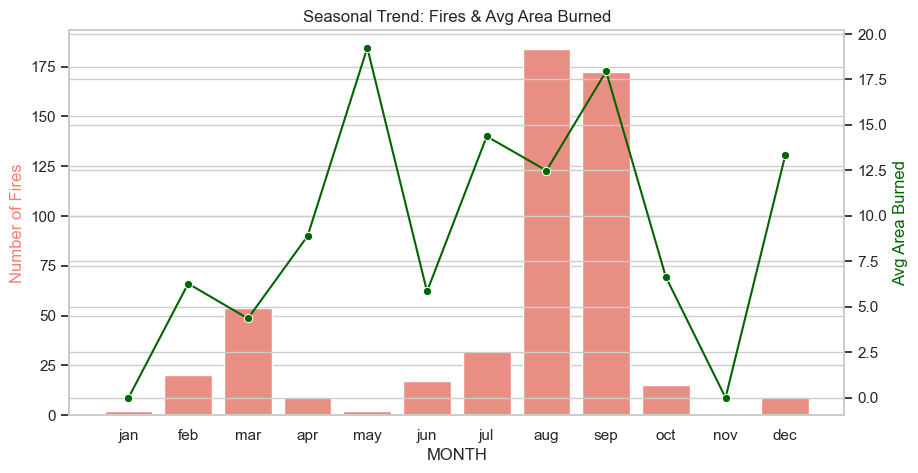

In [63]:
# 4. 🔁 Bonus: Seasonal Trend - Fires and Area per Month
monthly_trend = df.groupby('MONTH', observed=True).agg(
    fire_count=('AREA', 'count'),
    avg_area=('AREA', 'mean')
).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar plot for fire count
sns.barplot(x=monthly_trend.index, y=monthly_trend['fire_count'], color='salmon', ax=ax1)
ax1.set_ylabel('Number of Fires', color='salmon')
ax1.set_title("Seasonal Trend: Fires & Avg Area Burned")

# Line plot for average area burned
ax2 = ax1.twinx()
sns.lineplot(x=monthly_trend.index, y=monthly_trend['avg_area'], color='darkgreen', marker='o', ax=ax2)
ax2.set_ylabel('Avg Area Burned', color='darkgreen')

plt.show()


### 2. Here are five key outcomes from your analysis:
### OBJECTIVE 2: Understand the temporal pattern of forest fires by month and day
* Data Preprocessing: The MONTH and DAY columns were converted to lowercase, mapped to their respective abbreviations, and set as categorical variables to ensure correct ordering for plots.
* Fire Size Categories: Fires were categorized as 'small' or 'large' based on the 'AREA' column, helping to distinguish between the two categories in subsequent analyses.
* Monthly Fire Trends: The countplot for fires by month reveals the seasonal pattern of fires, highlighting the months with more frequent fires and distinguishing between small and large fires.
* Daily Fire Trends: The countplot for fires by day of the week shows how fire frequency varies by day, with insights into whether weekends or weekdays are more prone to certain fire sizes.
* Seasonal Trend of Fires: The combined bar and line plot displays the number of fires and the average area burned by month, revealing seasonal trends, with larger fires occurring in certain months. This helps understand both fire frequency and intensity across the year.

### Explore the relationship between weather conditions and fire spread

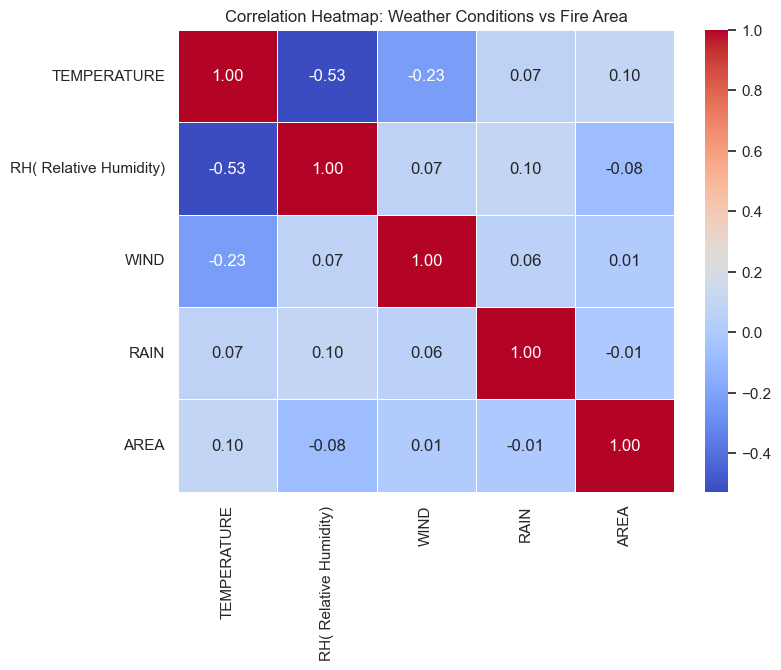

In [70]:
# Calculate correlation matrix
correlation_matrix = df[['TEMPERATURE', 'RH( Relative Humidity)', 'WIND', 'RAIN', 'AREA']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Weather Conditions vs Fire Area')
plt.show()


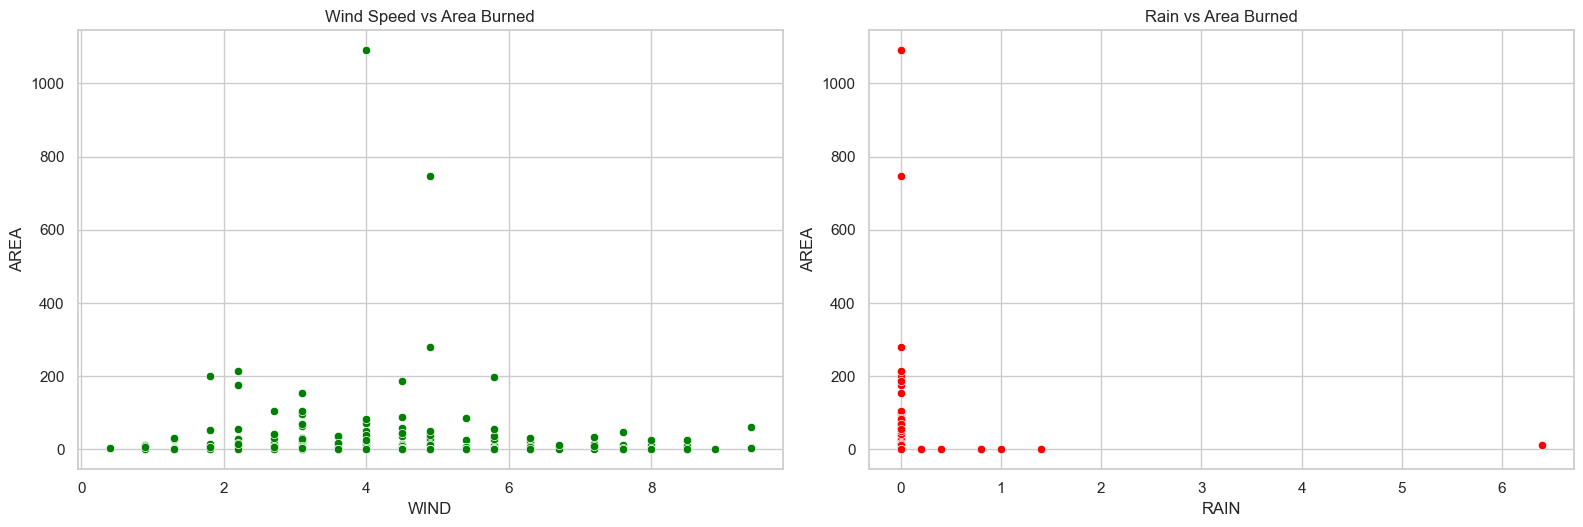

In [91]:
# Scatter plot: Wind vs Area
plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='WIND', y='AREA', color='green')
plt.title('Wind Speed vs Area Burned')

# Scatter plot: Rain vs Area
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='RAIN', y='AREA', color='red')
plt.title('Rain vs Area Burned')
plt.tight_layout()

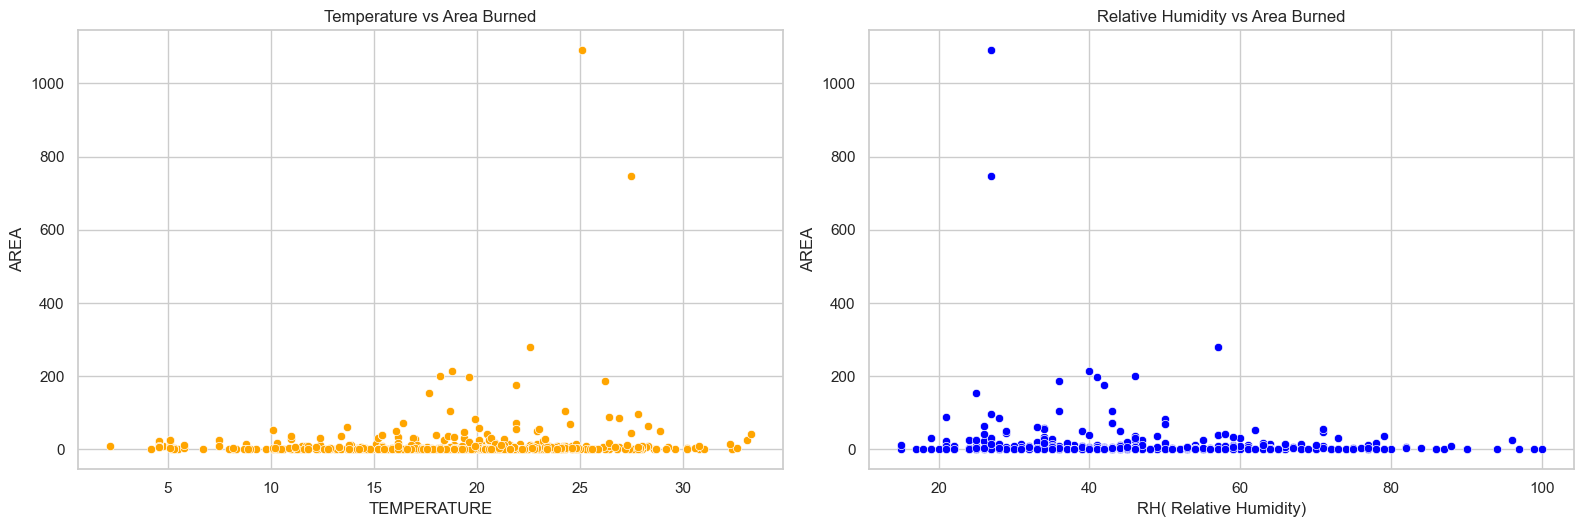

In [93]:
# Scatter plots for weather conditions vs. Area burned
plt.figure(figsize=(16, 10))

# Scatter plot: Temp vs Area
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='TEMPERATURE', y='AREA', color='orange')
plt.title('Temperature vs Area Burned')

# Scatter plot: RH vs Area
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='RH( Relative Humidity)', y='AREA', color='blue')
plt.title('Relative Humidity vs Area Burned')

plt.tight_layout()
plt.show()


### Expected Outcomes:
### Explore the relationship between weather conditions and fire spread
* Scatter Plots: These will show the relationship between each weather condition and fire area, highlighting any visible trends (e.g., higher temperature or lower humidity leading to larger fires).
* Heatmap: The correlation matrix will help you identify which weather conditions have the highest positive or negative correlation with the area burned. For example, temperature may have a strong positive correlation with the fire area.
* Pearson Correlation Coefficients: These will quantify the relationship. A value close to +1 or -1 indicates a strong relationship, while values near 0 suggest a weak or no linear relationship.
* Regression Line: Adding regression lines to the scatter plots helps to visualize the linear trend, and the coefficient will indicate the strength and direction of that trend (positive or negative).

### 4. Map fire frequency and size across geographic coordinates (X, Y)

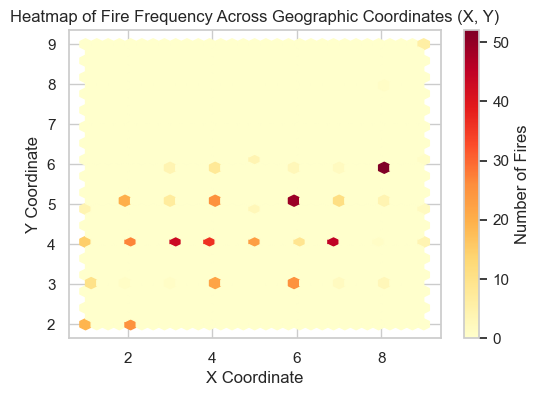

In [98]:
# Heatmap of fire frequency across geographic coordinates (X, Y) using matplotlib's hexbin
plt.figure(figsize=(6,4))
plt.hexbin(df['X'], df['Y'], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Number of Fires')
plt.title('Heatmap of Fire Frequency Across Geographic Coordinates (X, Y)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


### Expected Outcomes:
### Map fire frequency and size across geographic coordinates (X, Y)
* Fire Frequency Hotspots: The heatmap will reveal areas where fires are most frequent, potentially highlighting regions within the park that need more attention or monitoring.
* Severe Fire Locations: The scatter plot will show areas where fires burn the largest areas, indicating spots with more severe fire occurrences.
* Geographic Trends: By analyzing these plots together, you can identify patterns or correlations between fire occurrence and specific geographic regions within the park, leading to more effective resource allocation or fire prevention strategies.

### Study relationships between Fire Weather Index values and fire behavior

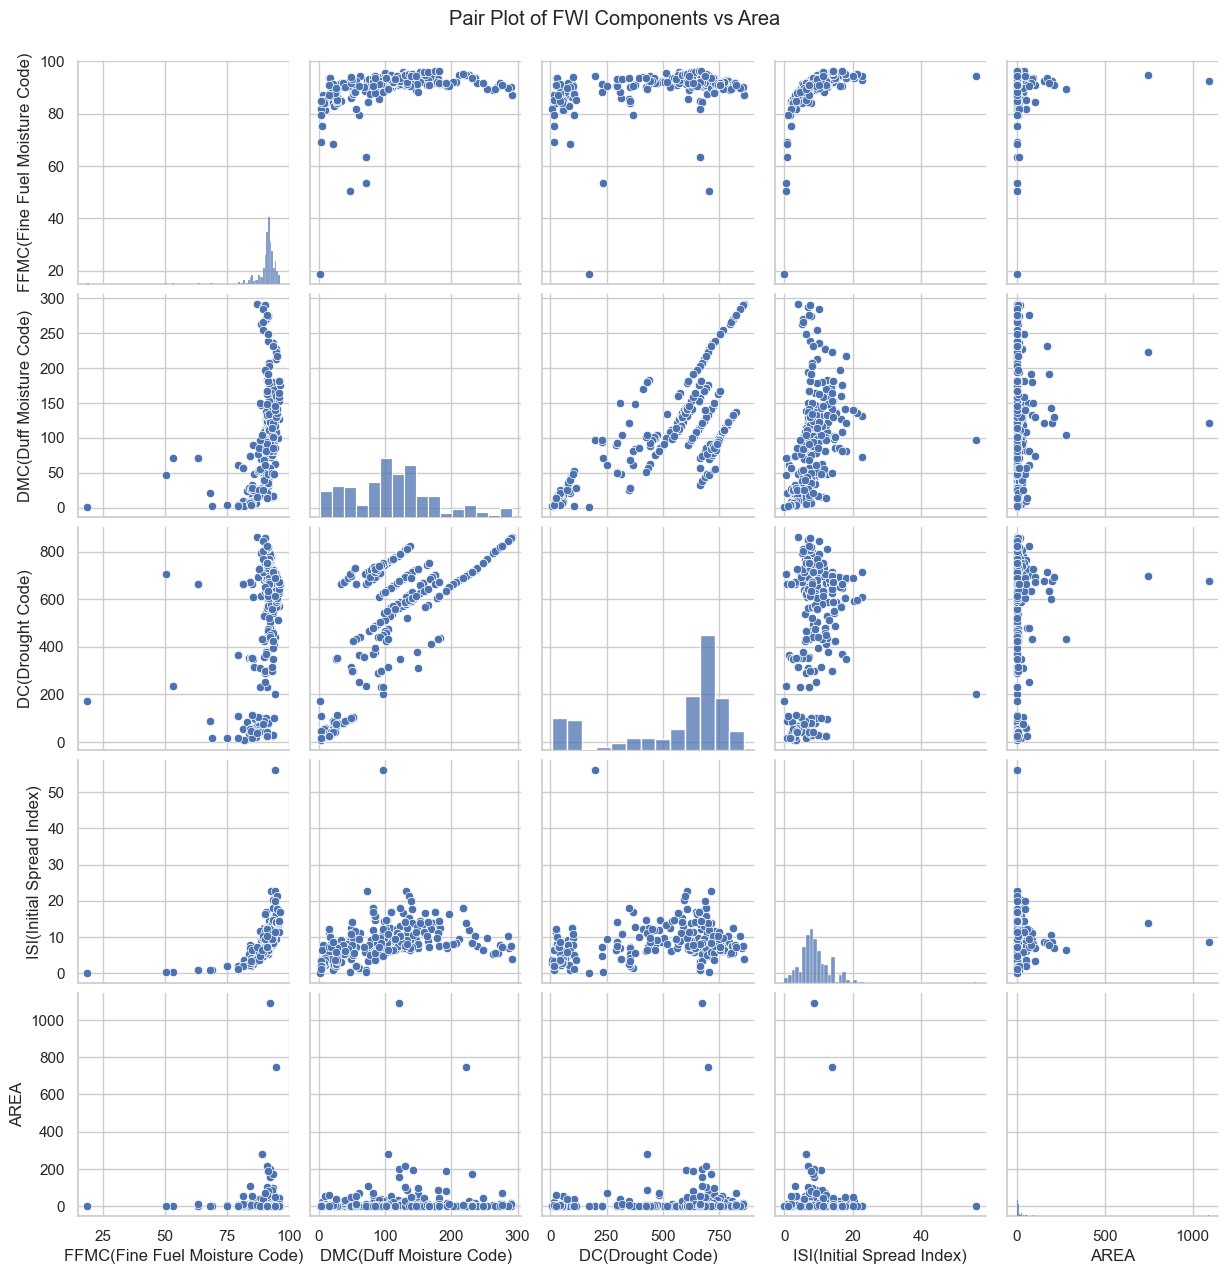

In [75]:
# Pair plot of FFMC, DMC, DC, ISI vs Area
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns for the pair plot
fwi_columns = ['FFMC(Fine Fuel Moisture Code)', 'DMC(Duff Moisture Code)', 'DC(Drought Code)', 'ISI(Initial Spread Index)', 'AREA']

# Plot pair plot
sns.pairplot(df[fwi_columns])
plt.suptitle('Pair Plot of FWI Components vs Area', y=1.02)
plt.show()


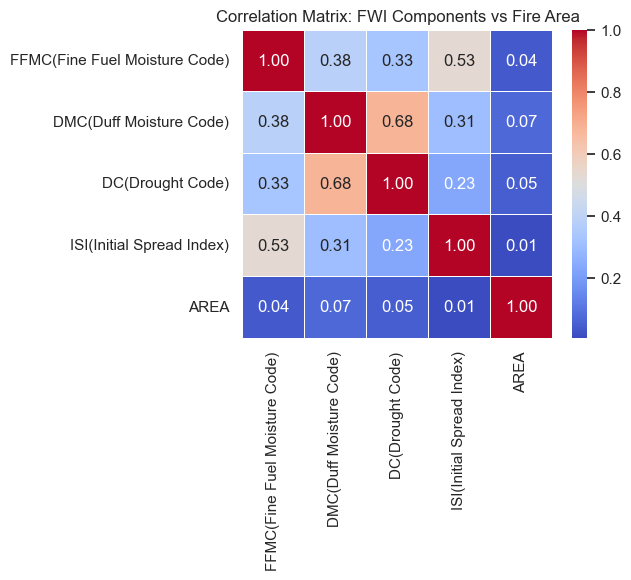

In [99]:
# Calculate correlation matrix
correlation_matrix = df[['FFMC(Fine Fuel Moisture Code)', 'DMC(Duff Moisture Code)', 'DC(Drought Code)', 'ISI(Initial Spread Index)', 'AREA']
].corr()

# Plot heatmap of the correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: FWI Components vs Fire Area')
plt.show()


### Expected Outcomes:
### Study relationships between Fire Weather Index values and fire behavior
* Pair Plot: Helps visualize potential relationships between FWI components and fire area. You might see that some components (e.g., FFMC or ISI) show stronger relationships with fire size.
* Correlation Matrix: This will provide a quantitative measure of how strongly each weather index is related to fire area. For example, a high correlation between ISI and fire area suggests that ISI is a good predictor for fire intensity.

### Classify fire severity into levels and analyze their distribution

In [78]:
# Classify fire severity based on area
def classify_severity(area):
    if area == 0:
        return 'Low'
    elif 0 < area <= 10:
        return 'Moderate'
    else:
        return 'Severe'

df['fire_severity'] = df['AREA'].apply(classify_severity)

# Verify the new column
df['fire_severity'].value_counts()


fire_severity
Low         247
Moderate    175
Severe       95
Name: count, dtype: int64

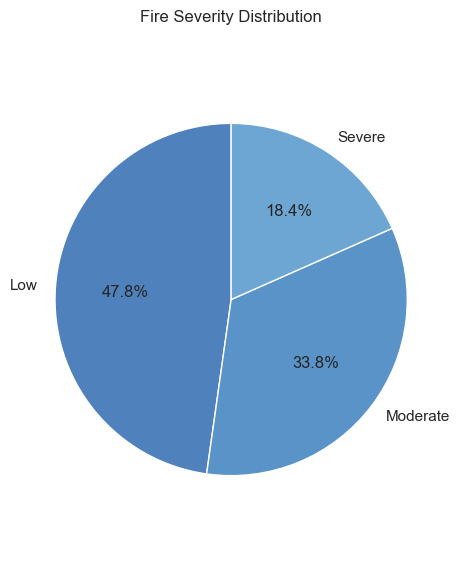

In [100]:
# Pie chart for fire severity distribution with cool-toned colors
plt.figure(figsize=(5,7))
severity_counts = df['fire_severity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4f81bd', '#5a93c7', '#6da6d2'])
plt.title('Fire Severity Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [87]:
# Calculate average temperature, wind, and other factors by severity class
severity_avg = df.groupby('fire_severity').agg(
    avg_temp=('TEMPERATURE', 'mean'),
    avg_wind=('WIND', 'mean'),
    avg_rh=('RH( Relative Humidity)', 'mean')
).reset_index()

# Display the result
print(severity_avg)

  fire_severity   avg_temp  avg_wind     avg_rh
0           Low  18.427935  3.913360  44.894737
1      Moderate  19.449143  4.008571  44.194286
2        Severe  19.056842  4.305263  42.884211


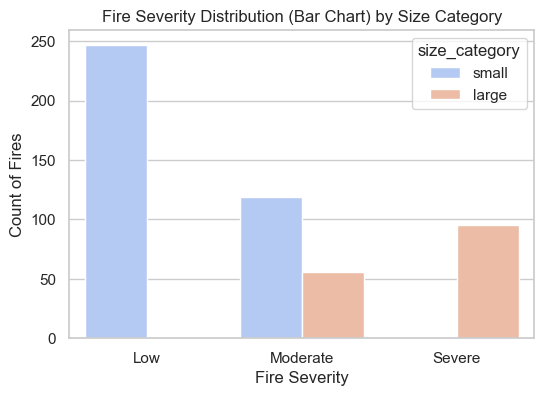

In [101]:
# Bar chart for fire severity distribution with hue (e.g., by size category)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fire_severity', hue='size_category', palette='coolwarm')
plt.title('Fire Severity Distribution (Bar Chart) by Size Category')
plt.xlabel('Fire Severity')
plt.ylabel('Count of Fires')
plt.show()


### Classify fire severity into levels and analyze their distribution
* Distribution: The pie chart and bar chart will give you a clear idea of how the fires are distributed across severity levels (Low, Moderate, Severe). You can analyze whether most fires are small (low severity) or large (severe).
* Average Environmental Conditions: By analyzing the average temperature, wind, and humidity per severity level, you can understand how these conditions influence fire behavior. For instance, you might find that severe fires occur in higher temperatures and stronger winds.